# 🚀 Multiple Linear Regression: The 50 Startups Challenge

Welcome to the next level of Regression! In Simple Linear Regression, we had only **one** feature. Now, we are stepping into the real world where multiple factors influence an outcome.

### 💼 The Business Challenge
You are hired as a Data Scientist by a **Venture Capitalist (VC) Fund**. 
They have given you a dataset of **50 startups** and want you to build a model to help them decide which types of companies to invest in to maximize profit.

**The Dataset Contains:**
* **R&D Spend** (Independent Variable)
* **Administration Spend** (Independent Variable)
* **Marketing Spend** (Independent Variable)
* **State** (Categorical Independent Variable: NY, CA, FL)
* **Profit** (Dependent Variable - *The Target*)

Your goal: Build a model that predicts **Profit** based on the other four variables!

## 🧮 The Multiple Linear Regression Equation

The equation is a direct extension of Simple Linear Regression. Instead of one slope, we have a slope for every single feature:

$$y = b_0 + b_1x_1 + b_2x_2 + ... + b_nx_n$$

* **$y$**: Dependent variable (Profit)
* **$b_0$**: Y-Intercept (Base profit)
* **$b_1, b_2, ...$**: Slope coefficients for each feature
* **$x_1, x_2, ...$**: Independent variables (R&D, Admin, Marketing, State)

### 🥔 Intuition Example: Potato Yield
Imagine predicting potato yield ($y$) based on:
1. Fertilizer ($x_1$)
2. Temperature ($x_2$)
3. Rainfall ($x_3$)

$$Yield = 8 + 3(Fertilizer) - 0.54(Temperature) + 0.04(Rainfall)$$
*Notice how temperature has a **negative** coefficient? The model learns that higher temperatures decrease the yield!*

## 📏 Assumptions of Linear Regression
Before applying linear regression in strict statistical analysis, we assume 5 conditions are met. 

1. **Linearity**: The relationship between X and Y is linear.
2. **Homoscedasticity**: Equal variance of residuals (no "cone" shapes in scatter plots).
3. **Multivariate Normality**: The residuals are normally distributed.
4. **Independence of Observations**: No autocorrelation (e.g., stock market prices affect each other).
5. **Lack of Multicollinearity**: Independent variables are not highly correlated with *each other*.

###  The Danger of Multicollinearity

#### ⚠️ What is Multicollinearity?
Multicollinearity occures when, two or more independent variables contain similar informaiton. In other words, one feature can be predicted using another feature. 

Imagine you have two features: **Age** and **Birth Year**. 
If Age = 25, then Birth Year ≈ Current Year - 25. Both columns contain almost identical information! 
**Result:** The model gets confused, and the coefficients become highly unstable and difficult to interpret.

### Does multicollinearity affect prediction accuracy?
Surprisingl, not always. It mainly affects coefficient interpretation which is why it's a much bigger issue in:
* Statistics
* Econometrics
* Business Analytics
than in pure prediction-focused ML.

--- 
#### 📊 Measuring Multicollinearity: VIF (Variance Inflation Factor)
VIF measures how much a feature can be explained by all other features.

| VIF Score | Interpretation |
| :--- | :--- |
| **1** | No correlation |
| **1 - 5** | Acceptable |
| **> 5** | High correlation (investigate) |
| **> 10** | Severe Multicollinearity (remove feature) |

**Code to check VIF:**
```python
from statsmodels.stats.outliers_influence import variance_inflation_factor
vif = pd.DataFrame()
vif["Feature"] = X.columns
vif["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
print(vif)
```


🔍 **Extra Check: Outliers**
Outliers can heavily skew the regression line. We must decide whether to remove them based on business logic.

> 🤯 **Fun Fact: The Anscombe Quartet**
> In 1973, statistician Francis Anscombe created 4 datasets that have the *exact same* mean, variance, and regression line, but look completely different when graphed (one is a curve, one has an outlier, etc.). This proves why you must always visualize your data and not just trust the math!

## Dummy Variables & The Dummy Variable Trap

### What is a Dummy Variable?
Our dataset has a categorical column: **State** (New York, California, Florida). 
Math equations cannot process text! We must convert categories into numbers using **One-Hot Encoding**. They act like **light switches** (1 = ON, 0 = OFF).

| State | ➡️ | New York | California | Florida |
| :--- | :---: | :---: | :---: | :---: |
| NY | ➡️ | 1 | 0 | 0 |
| CA | ➡️ | 0 | 1 | 0 |
| FL | ➡️ | 0 | 0 | 1 |

### ⚠️ The Dummy Variable Trap
If we include **all three** dummy columns *and* the constant ($b_0$), we create **perfect multicollinearity**. 
Why? Because $NY + CA + FL = 1$, which perfectly duplicates the constant $b_0$! The model's math will break.

```text
  ❌ WRONG (The Trap)
  Equation: y = b0 + b1(NY) + b2(CA) + b3(FL)
  Problem: NY + CA + FL = 1 (Duplicates b0!)
  Result: Multicollinearity -> Model Breaks 💥
  
  ✅ CORRECT (The Solution)
  Equation: y = b0 + b1(NY) + b2(CA)
  Baseline: If NY=0 and CA=0 -> It MUST be FL!
  Result: Clean Math -> Model Works 🎉
```
  **The Golden Rule:** Always drop **one** dummy variable ($N-1$ rule). The dropped category becomes the "baseline".

`Scikit-learn`'s `LinearRegression` **class automatically avoids the Dummy Variable Trap!** When you use `drop='first'` in **OneHotEncoder**, it handles this automatically.




## P-Values & The "Coin Toss" Intuition

How do we know if a feature (like Marketing Spend) actually impacts Profit, or if it's just random noise? We use **P-Values**.

**The Intuition:**
Imagine you assume a coin is fair (Null Hypothesis, $H_0$). You toss it 5 times and get 5 Tails in a row. 
The probability of this happening by random chance is $(0.5)^5 = 3\%$. 
Because $3\%$ is so low (less than our standard $5\%$ threshold), you reject the idea that the coin is fair. You conclude the coin is rigged!

**In Machine Learning:**
* **Null Hypothesis ($H_0$)**: "This feature has NO effect on the target."
* **P-Value**: The probability that the feature's impact is just random noise.
* **Significance Level ($\alpha$)**: Usually set to **0.05 (5%)**.


**The Rule:** If **P < 0.05**, we reject the Null Hypothesis. The feature is **statistically significant** and we keep it!
> * **P < 0.05**: Statistically significant. Keep the feature!
> * **P > 0.05**: Not significant. Consider removing it.

## 🏗️ How to Build the Best Model? (Stepwise Methods)
When you have many features, which ones should you keep? There are 5 methods:

1. **All-In**: Throw all variables in. (Use only if you have prior domain knowledge).
2. **Backward Elimination**: 
   ```text
   [ Start with ALL Variables ]
             ↓
   [ Find Highest P-Value ]
             ↓
   [ Is P > 0.05? ] --(No)--> [ FINISH: Model Ready! ✅ ]
             ↓ (Yes)
   [ Remove Variable & Refit ]
             ↓
       (Loop back)
   ```
3. **Forward Selection**: Start with 1 variable. Add the one with the lowest p-value. Repeat.
4. **Bidirectional Elimination**: Combine Forward and Backward.
5. **Score Comparison**: Build all possible combinations ($2^n - 1$) and compare R² scores.

> 🚨 **CRITICAL CORRECTION:** Scikit-Learn's `LinearRegression` does **NOT** perform feature selection automatically. It simply calculates coefficients for whatever you feed it. If you want to do strict Backward Elimination using P-values, you must use the `statsmodels` library. However, in modern ML pipelines, we often just feed all features to Scikit-Learn, evaluate the accuracy, and rely on the algorithm to assign tiny coefficients to useless features!

## 🛠️ Step 1: Data Preprocessing

* **Handling 'State'**: We will use `ColumnTransformer` and `OneHotEncoder`. **We must use `drop='first'`** to avoid the Dummy Variable Trap.
* **No Feature Scaling?** Correct! OLS adjusts the coefficients automatically. If R&D is in millions and Marketing is in thousands, the model simply assigns a tiny coefficient to R&D and a larger one to Marketing. No scaling needed!

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import os
import seaborn as sns

# --- Dataset Loading & Synthetic Generator ---
csv_path = '50_Startups.csv'
if not os.path.exists(csv_path):
    print("⚠️ '50_Startups.csv' not found. Generating synthetic data...")
    np.random.seed(42)
    n = 50
    rd = np.random.uniform(10000, 200000, n)
    admin = np.random.uniform(10000, 150000, n)
    marketing = np.random.uniform(10000, 100000, n)
    states = np.random.choice(['New York', 'California', 'Florida'], n)
    profit = 20000 + 0.6*rd + 0.2*marketing + 0.1*admin + np.random.normal(0, 10000, n)
    df = pd.DataFrame({'R&D Spend': rd, 'Administration': admin, 'Marketing Spend': marketing, 'State': states, 'Profit': profit})
    df.to_csv(csv_path, index=False)
    print("✅ Synthetic '50_Startups.csv' created!")

# 1. Import Dataset
dataset = pd.read_csv(csv_path)
X = dataset.iloc[:, :-1].values # All independent variables
y = dataset.iloc[:, -1].values  # Dependent variable (Profit)

# 2. Encoding categorical data (One-Hot Encoding for 'State' at index 3)
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
ct = ColumnTransformer(transformers=[('encoder', OneHotEncoder(), [3])], remainder='passthrough')
X = np.array(ct.fit_transform(X))

# 3. Splitting the dataset into the Training set and Test set
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 0)

print(f"✅ Data Preprocessed! X_train shape: {X_train.shape}")

⚠️ '50_Startups.csv' not found. Generating synthetic data...
✅ Synthetic '50_Startups.csv' created!
✅ Data Preprocessed! X_train shape: (40, 6)


## 🧠 Step 2: Training the Multiple Linear Regression Model

The beauty of `scikit-learn` is that the `LinearRegression` class is exactly the same as the one we used for Simple Linear Regression. 
1. It automatically handles the **Dummy Variable Trap** behind the scenes.
2. It automatically calculates the optimal coefficients for all features.

All we have to do is instantiate the class and call `.fit()`.

### 🔍 How to Interpret the Coefficients
Suppose the model learns the following equation:
$$Profit = 50000 + 0.8(R\&D) + 0.05(Marketing) - 0.02(Admin)$$

* **R&D ($0.8$)**: For every **$1 increase** in R&D spend, Profit increases by **$0.80**, *holding all other variables constant*.
* **Marketing ($0.05$)**: For every **$1 increase** in Marketing, Profit increases by **$0.05**, *holding others constant*.
* **Admin ($-0.02$)**: For every **$1 increase** in Admin costs, Profit *decreases* by **$0.02**, *holding others constant*.

*(Notice how we must always add "holding others constant" — that is the magic of Multiple Linear Regression!)*

In [2]:
from sklearn.linear_model import LinearRegression

# Create the model object
regressor = LinearRegression()

# Train the model on the Training set
regressor.fit(X_train, y_train)

print("🎉 Model trained successfully!")
print(f"📌 Intercept (b0): ${regressor.intercept_:,.2f}")
print(f"📌 Coefficients: {np.round(regressor.coef_, 2)}")

🎉 Model trained successfully!
📌 Intercept (b0): $20,984.01
📌 Coefficients: [-3.73435e+03  2.57750e+02  3.47660e+03  6.00000e-01  1.20000e-01
  1.70000e-01]


## 🔮 Step 3: Predicting & Evaluating

Because we have multiple dimensions, we can't plot a simple 2D line. Instead, we will:
1. Compare the **Predicted Vector** vs the **Real Vector**.
2. Calculate modern evaluation metrics: **R², Adjusted R², MAE, RMSE**.
3. Plot a **Residual Plot** to check for non-linearity.

### 📊 R² vs Adjusted R²
* **R² (0.85)**: "85% of the variance in Profit is explained by the model."
* **The Problem with R²**: It *always* increases when you add more features, even useless ones!
* **The Solution (Adjusted R²)**: It penalizes the score for adding unnecessary features. It only goes up if the new variable genuinely improves the model.

📊 Predicted vs Real Profits (Test Set):
[[103257.41 124412.37]
 [147033.21 144003.37]
 [ 43220.64  51210.31]
 [104999.36  84259.56]
 [133303.82 131886.95]
 [102862.66  85287.22]
 [131007.47 134470.08]
 [ 63023.2   46180.91]
 [ 71426.53  63480.59]
 [ 67503.4   70023.47]]


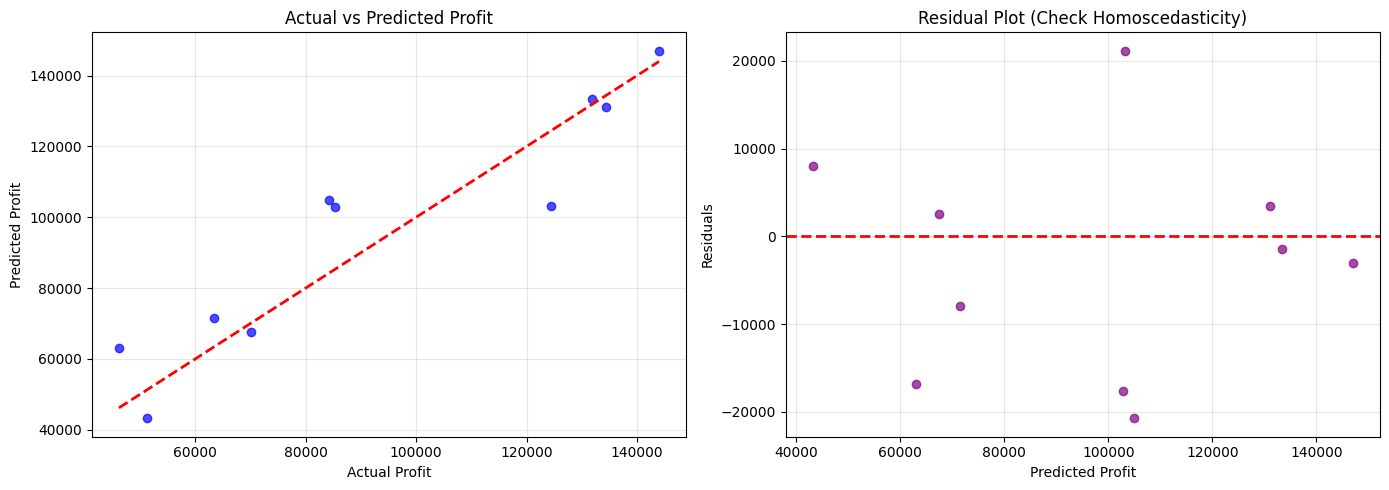


📈 Model R² Score: 0.8676
📉 Mean Absolute Error: $10,267.75


In [6]:
# 1. Predicting the Test set results
y_pred = regressor.predict(X_test)

# 2. The Transcript Method: Displaying vectors side-by-side
np.set_printoptions(precision=2)
print("📊 Predicted vs Real Profits (Test Set):")
print(np.concatenate((y_pred.reshape(len(y_pred), 1), y_test.reshape(len(y_test), 1)), 1))

# ==========================================
# 🌟 BONUS: Modern ML Visualizations
# ==========================================
from sklearn.metrics import r2_score, mean_absolute_error

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Actual vs Predicted
axes[0].scatter(y_test, y_pred, color='blue', alpha=0.7)
# Draw a perfect prediction line (y = x)
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axes[0].set_title('Actual vs Predicted Profit')
axes[0].set_xlabel('Actual Profit')
axes[0].set_ylabel('Predicted Profit')
axes[0].grid(True, alpha=0.3)

# Plot 2: Residuals (Error Distribution)
residuals = y_test - y_pred
axes[1].scatter(y_pred, residuals, color='purple', alpha=0.7)
axes[1].axhline(y=0, color='red', linestyle='--', lw=2)
axes[1].set_title('Residual Plot (Check Homoscedasticity)')
axes[1].set_xlabel('Predicted Profit')
axes[1].set_ylabel('Residuals')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\n📈 Model R² Score: {r2_score(y_test, y_pred):.4f}")
print(f"📉 Mean Absolute Error: ${mean_absolute_error(y_test, y_pred):,.2f}")

## 🎤 Top Interview Questions

**Q1: Why don't we need Feature Scaling for Linear Regression?**
> **A:** Because the equation has coefficients ($b_1, b_2...$) for each feature. The model will naturally assign a very small coefficient to a feature with large values (like R&D in millions) and a larger coefficient to a feature with small values. The math compensates for the scale automatically.

**Q2: What is the Dummy Variable Trap and how you avoid it?**
> **A:** It occurs when you include all dummy variables (from One-Hot Encoding) AND the intercept constant in your model. This causes perfect **multicollinearity** because the dummy variables sum up to 1, which perfectly duplicates the intercept. The solution is to always drop one dummy variable ($n-1$ rule).

**Q3: Does `scikit-learn`'s `LinearRegression` automatically avoid the Dummy Variable Trap?**
> **A:** Yes! By default, `LinearRegression` sets `fit_intercept=True`. When it builds the model using matrix algebra, it inherently handles the redundancy, treating the first category as the baseline. However, manually dropping it via `drop='first'` in `OneHotEncoder` is considered best practice for data cleanliness.

**Q4: Do we need to manually perform Backward Elimination in Python?**
> **A:** In modern Machine Learning engineering, usually **no**. While Backward Elimination is great for statistical inference (finding p-values to explain to stakeholders), `scikit-learn`'s `LinearRegression` automatically finds the optimal mathematical coefficients for all features using Ordinary Least Squares (OLS). If the data is non-linear, the model will just perform poorly, signaling you to try a different algorithm (like Polynomial Regression or Random Forest) rather than manually tweaking p-values.

**Q5: What does a P-value of 0.03 mean in the context of feature selection?**
> **A:** It means there is only a 3% probability that the observed relationship between the feature and the target is due to random chance. Since 3% < 5% (our standard significance level), we reject the Null Hypothesis and conclude the feature is statistically significant.

**Q6: What is the difference between Simple and Multiple Linear Regression?**
> **A:** Simple LR uses exactly **1 feature** to predict a target. Multiple LR uses **2 or more features**.

**Q7: Why isn't feature scaling mandatory for Linear Regression?**
> **A:** Because OLS automatically adjusts the coefficients. A feature with massive values (like R&D in millions) will simply be assigned a tiny coefficient, while a feature with small values gets a larger coefficient. The math compensates for the scale.

**Q8: When does Linear Regression fail?**
> **A:** It fails when the relationship between X and Y is highly **non-linear** (e.g., exponential or parabolic). In those cases, you must use Polynomial Regression or Decision Trees.

**Q9: Why use Adjusted R² instead of R²?**
> **A:** Because standard R² *always* increases when you add more variables, even if they are useless noise. Adjusted R² introduces a penalty for adding unnecessary features, so it only increases if the new variable genuinely improves the model's predictive power.

**Q10: Does Scikit-Learn's `LinearRegression` automatically perform Backward Elimination?**
> **A:** **No.** Scikit-Learn simply calculates the OLS coefficients for all features you provide. It does not look at P-values to drop features. If you want strict statistical feature selection, you must use the `statsmodels` library. In modern ML, we usually just evaluate the model's accuracy and rely on Regularization (Lasso/Ridge) to handle feature selection.

**Q11: What is Multicollinearity?**
> **A:** It happens when independent variables are highly correlated with *each other* (e.g., "Age" and "Birth Year"). It makes the model's coefficients unstable and unreliable. We measure it using **VIF (Variance Inflation Factor)**.

**Q12: How does Linear Regression learn its coefficients?**
> **A:** By using **Ordinary Least Squares (OLS)**, which finds the coefficients that minimize the Residual Sum of Squares (the squared differences between actual and predicted values).


## 🎯 Summary & What's Next?

### What we learned:
* **Multiple Linear Regression** handles multiple independent variables.
* **OLS** minimizes the squared errors to find the best coefficients.
* **Categorical Data** must be converted to Dummy Variables (One-Hot Encoding).
* **The Dummy Variable Trap** is avoided by dropping one category ($N-1$ rule).
* **No Feature Scaling** is required because OLS handles it mathematically.
* We evaluate models using **Adjusted R², RMSE**, and **Residual Plots**.
* Scikit-Learn does **not** do feature selection automatically; it just fits the math.

### 🚀 Next Steps: Non-Linear Models!
What happens if the relationship between R&D spend and Profit isn't a straight line? What if it's a curve? 
Linear Regression will fail! In the next section, we will learn **Polynomial Regression** to capture those beautiful, non-linear curves.

*Until then, enjoy machine learning!* 🧠💻